In [1]:
import seaborn as sns
import ast
import pandas as pd
import matplotlib.pyplot as plt
from datasets import load_dataset
from adjustText import adjust_text

dataset = load_dataset('lukebarousse/data_jobs')
df = dataset['train'].to_pandas()

df['job_posted_date'] = pd.to_datetime(df.job_posted_date)
df['job_skills'] = df['job_skills'].apply(lambda x : ast.literal_eval(x) if pd.notna(x) else x)

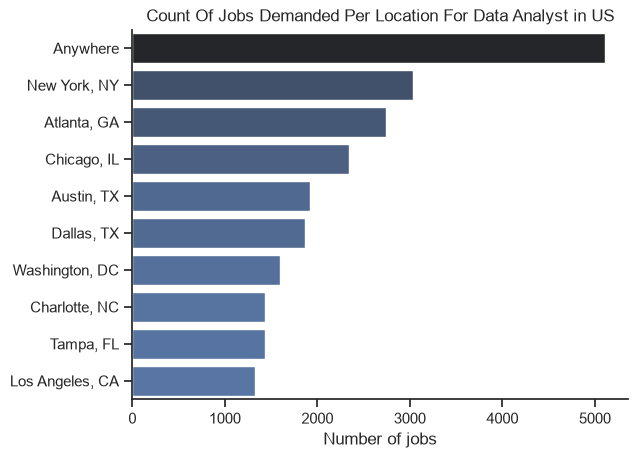

In [27]:
df_DA_US = df[(df['job_country'] == 'United States') & (df['job_title_short'] == 'Data Analyst')]

df_plot =   df_DA_US['job_location'].value_counts().head(10).to_frame()

sns.set_theme(style = 'ticks')
sns.barplot(data = df_plot, x = 'count', y = 'job_location', hue = 'count', palette = 'dark:b_r', legend = False)

sns.despine()
plt.title('Count Of Jobs Demanded Per Location For Data Analyst in US')
plt.ylabel('')
plt.xlabel('Number of jobs')
plt.show()

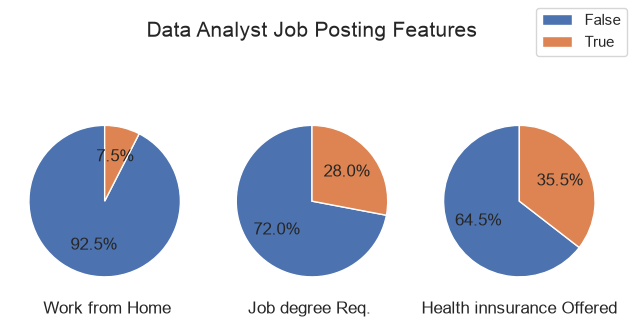

In [29]:
fig, ax = plt.subplots(1,3)

df[['job_work_from_home', 'job_no_degree_mention', 'job_health_insurance']]
Titles = {'job_work_from_home': ' Work from Home' , 'job_no_degree_mention':'Job degree Req. ', 'job_health_insurance': 'Health innsurance Offered'}

for i, (column,title) in enumerate(Titles.items()):
    counts = df_DA_US[column].value_counts()
    wedges,texts,autotexts = ax[i].pie(counts,startangle = 90, autopct = '%1.1f%%')
    ax[i].set_xlabel(title)      

fig.suptitle('Data Analyst Job Posting Features', fontsize = 15, y = 0.96)
fig.legend(wedges, counts.index)
fig.tight_layout(rect = [0, 0.30, 1, 0.95])
plt.show() 

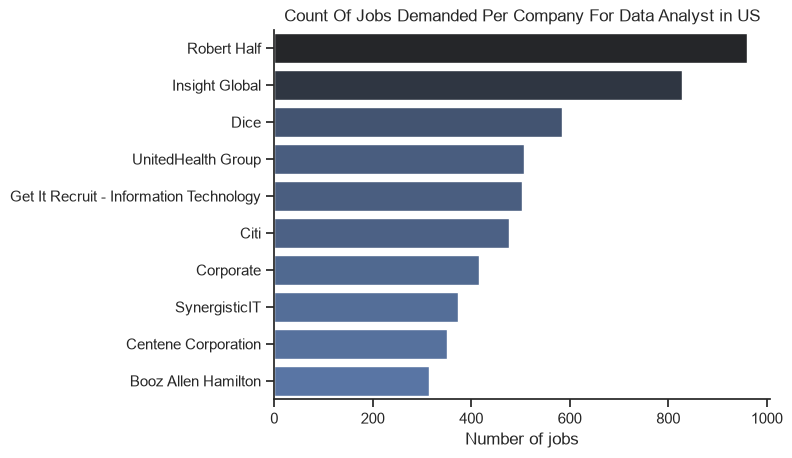

In [33]:
df_DA_US = df[(df['job_country'] == 'United States') & (df['job_title_short'] == 'Data Analyst')]

df_plot =   df_DA_US['company_name'].value_counts().head(10).to_frame()
df_plot
sns.set_theme(style = 'ticks')
sns.barplot(data = df_plot, x = 'count', y = 'company_name', hue = 'count', palette = 'dark:b_r', legend = False)

sns.despine()
plt.title('Count Of Jobs Demanded Per Company For Data Analyst in US')
plt.ylabel('')
plt.xlabel('Number of jobs')
plt.show()